# Playing Card Classification

This notebook assembles the saved full-dataset artifacts produced by the project pipeline. It reuses saved CSV, JSON, checkpoint, and PNG outputs rather than retraining in-place, which keeps the report reproducible and easy to review.

## Project Checklist

- Pretrained image-classification model: yes
- Transfer-learning approach: fine-tuning
- Classes: all 14 card ranks (`ace` through `joker`)
- Validation method: real stratified 5-fold cross-validation
- Standard visualizations: training curves, fold summary, confusion matrices, prediction galleries
- Feature maps: rendered for at least 2 face-card classes and 2 number-card classes
- Improvement pass: tracked separately if a refreshed post-baseline comparison artifact exists

## Notebook scope

The canonical dataset for this notebook is `data/processed/rank14_from_local_raw/`. Any earlier subset-era results are historical only and are not treated as directly comparable to the refreshed full-dataset baseline of record.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root containing AGENTS.md")


def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))


def show_image(path: Path, width: int = 900) -> None:
    display(Image(filename=str(path), width=width))


def metric_table(metrics: dict, keys: list[str]) -> pd.DataFrame:
    rows = []
    for key in keys:
        entry = metrics[key]
        rows.append(
            {
                "metric": key,
                "mean": entry["mean"],
                "std": entry["std"],
                "min": entry["min"],
                "max": entry["max"],
            }
        )
    return pd.DataFrame(rows)


def discover_result_summary() -> Path:
    candidates = sorted((REPO_ROOT / "outputs" / "logs").glob("*_aggregate_summary.json"))
    if not candidates:
        raise FileNotFoundError("No aggregate summary JSON was found.")

    canonical_rows = []
    for path in candidates:
        if "smoke" in path.name:
            continue
        payload = read_json(path)
        dataset_root = str(payload.get("dataset_root", ""))
        if "rank14_from_local_raw" not in dataset_root:
            continue
        canonical_rows.append(
            (
                payload["aggregate_metrics"]["val_accuracy_at_best_epoch"]["mean"],
                payload["aggregate_metrics"]["val_loss_at_best_epoch"]["mean"],
                payload["run_name"],
                path,
            )
        )

    if canonical_rows:
        canonical_rows.sort(key=lambda row: (-row[0], row[1], row[2]))
        return canonical_rows[0][3]

    non_smoke = [path for path in candidates if "smoke" not in path.name]
    refresh = [path for path in non_smoke if "refresh" in path.name]
    baseline = [path for path in non_smoke if "baseline" in path.name]
    if refresh:
        return refresh[-1]
    if baseline:
        return baseline[-1]
    if non_smoke:
        return non_smoke[-1]
    return candidates[-1]


def discover_stage7_summary(run_name: str) -> Path:
    candidates = sorted((REPO_ROOT / "outputs" / "feature_maps" / run_name).glob("best_fold_*/stage7_summary.json"))
    if not candidates:
        raise FileNotFoundError(f"No Stage 7 summary was found for run '{run_name}'.")
    return candidates[-1]


def discover_related_comparison(run_name: str) -> Path | None:
    comparison_paths = sorted((REPO_ROOT / "outputs" / "logs").glob("*_comparison.json"), reverse=True)
    for path in comparison_paths:
        payload = read_json(path)
        if payload.get("improved_run_name") == run_name:
            return path
    for path in comparison_paths:
        payload = read_json(path)
        if payload.get("baseline_run_name") == run_name:
            return path
    return None


def comparison_csv_path(comparison_json_path: Path, comparison_payload: dict) -> Path:
    artifacts = comparison_payload.get("artifacts", {})
    if "comparison_csv" in artifacts:
        return Path(artifacts["comparison_csv"])
    return comparison_json_path.with_name(comparison_json_path.name.replace("_comparison.json", "_per_fold_comparison.csv"))


REPO_ROOT = find_repo_root()
stage5_summary_path = discover_result_summary()
stage5_summary = read_json(stage5_summary_path)
run_name = stage5_summary["run_name"]
stage7_summary_path = discover_stage7_summary(run_name)
stage7_summary = read_json(stage7_summary_path)
improvement_comparison_path = discover_related_comparison(run_name)
stage8_comparison = read_json(improvement_comparison_path) if improvement_comparison_path else None
stage8_comparison_csv_path = (
    comparison_csv_path(improvement_comparison_path, stage8_comparison)
    if improvement_comparison_path and stage8_comparison
    else None
)

PATHS = {
    "dataset_summary": REPO_ROOT / "data" / "processed" / "rank14_from_local_raw" / "summary.json",
    "stage5_summary": stage5_summary_path,
    "stage5_per_fold": Path(stage5_summary["artifacts"]["per_fold_results_csv"]),
    "stage6_summary": REPO_ROOT / "outputs" / "visualizations" / run_name / "stage6_summary.json",
    "stage6_fold_table": REPO_ROOT / "outputs" / "visualizations" / run_name / "curves" / "fold_summary_table.csv",
    "stage6_predictions": REPO_ROOT / "outputs" / "visualizations" / run_name / "predictions" / "aggregate_validation_predictions.csv",
    "stage6_misclassifications": REPO_ROOT / "outputs" / "visualizations" / run_name / "predictions" / "aggregate_misclassifications.csv",
    "stage6_curves_png": REPO_ROOT / "outputs" / "visualizations" / run_name / "curves" / "training_validation_curves.png",
    "stage6_fold_chart_png": REPO_ROOT / "outputs" / "visualizations" / run_name / "curves" / "fold_summary_chart.png",
    "stage6_confusion_counts_png": REPO_ROOT / "outputs" / "visualizations" / run_name / "confusion" / "aggregate_confusion_matrix_counts.png",
    "stage6_confusion_normalized_png": REPO_ROOT / "outputs" / "visualizations" / run_name / "confusion" / "aggregate_confusion_matrix_normalized.png",
    "stage6_prediction_gallery_png": REPO_ROOT / "outputs" / "visualizations" / run_name / "predictions" / "prediction_gallery.png",
    "stage6_misclassification_gallery_png": REPO_ROOT / "outputs" / "visualizations" / run_name / "predictions" / "misclassification_gallery.png",
    "stage7_summary": stage7_summary_path,
    "stage7_examples_csv": Path(stage7_summary["artifacts"]["selected_examples_csv"]),
    "stage7_overview_png": Path(stage7_summary["artifacts"]["overview_png"]),
    "stage7_dir": Path(stage7_summary["artifacts"]["output_root"]),
}

dataset_summary = read_json(PATHS["dataset_summary"])
stage6_summary = read_json(PATHS["stage6_summary"])
stage5_per_fold = pd.read_csv(PATHS["stage5_per_fold"])

print(f"Repo root: {REPO_ROOT}")
print(f"Loaded full-dataset artifacts for run: {run_name}")
if improvement_comparison_path:
    print(f"Loaded refreshed improvement comparison: {improvement_comparison_path.name}")
else:
    print("No refreshed post-baseline comparison artifact was loaded.")

Repo root detected
Loaded full-dataset artifacts for run: stage8_refresh_resnet50_ft_linear_lr1e4_e3
Loaded refreshed improvement comparison: stage8_refresh_resnet50_ft_linear_lr1e4_e3_comparison.json


## Dataset Summary

The canonical dataset for this project is the derived 14-rank local dataset at `data/processed/rank14_from_local_raw/`. It collapses suit-specific labels into rank targets while keeping all 14 classes available for cross-validation.

The main caveat is still class imbalance. `ace`, `eight`, and `five` are common, while `joker` has only 5 images total. That affects how confidently we should interpret per-class behavior, especially in the confusion matrices.

In [2]:
rank_counts = (
    pd.Series(dataset_summary["rank_counts"], name="image_count")
    .rename_axis("class_name")
    .reset_index()
    .sort_values("image_count", ascending=False)
)
rank_counts["dataset_share"] = (rank_counts["image_count"] / rank_counts["image_count"].sum()).round(4)

dataset_overview = pd.DataFrame(
    [
        {"field": "Dataset root", "value": dataset_summary["output_root"]},
        {"field": "Manifest", "value": dataset_summary["manifest_csv"]},
        {"field": "Link mode", "value": dataset_summary["link_mode"]},
        {"field": "Total images", "value": dataset_summary["total_images"]},
        {"field": "Distinct classes", "value": len(dataset_summary["rank_counts"])},
        {"field": "Source train images", "value": dataset_summary["source_split_counts"]["train"]},
        {"field": "Source test images", "value": dataset_summary["source_split_counts"]["test"]},
    ]
)

display(dataset_overview)
display(rank_counts)
display(
    Markdown(
        f"Each class has at least 5 images, so strict 5-fold stratified CV is feasible. "
        f"The smallest class is `joker` with {dataset_summary['rank_counts']['joker']} images."
    )
)

,field,value
0,Dataset root,C:\Users\golde\OneDrive - University of Virgin...
1,Manifest,C:\Users\golde\OneDrive - University of Virgin...
2,Link mode,hardlink
3,Total images,8154
4,Distinct classes,14
5,Source train images,7624
6,Source test images,265


,class_name,image_count,dataset_share
10,jack,711,0.0872
11,queen,665,0.0816
0,ace,641,0.0786
7,eight,624,0.0765
4,five,622,0.0763
9,ten,619,0.0759
5,six,616,0.0755
1,two,613,0.0752
3,four,605,0.0742
8,nine,580,0.0711


Each class has at least 5 images, so strict 5-fold stratified CV is feasible. The smallest class is `joker` with 125 images.

## Model Choice And Cross-Validation Design

The notebook loads the strongest saved canonical full-dataset run dynamically. At build time this can be either the refreshed `ResNet18` rerun or the bounded `ResNet50` escalation, depending on which saved 5-fold mean validation accuracy is higher.

In [3]:
baseline_config = pd.DataFrame(
    [
        {"setting": "Run name", "value": stage5_summary["run_name"]},
        {"setting": "Backbone", "value": stage5_summary["model_name"]},
        {"setting": "Pretrained backbone", "value": stage5_summary["pretrained_backbone"]},
        {
            "setting": "Transfer strategy",
            "value": "bottleneck / frozen backbone" if stage5_summary["freeze_backbone"] else "full fine-tuning",
        },
        {"setting": "Optimizer", "value": stage5_summary["optimizer_name"]},
        {"setting": "Scheduler", "value": stage5_summary["scheduler_name"]},
        {"setting": "Folds", "value": stage5_summary["num_folds"]},
        {"setting": "Epochs per fold", "value": stage5_summary["num_epochs"]},
        {"setting": "Batch size", "value": stage5_summary["batch_size"]},
        {"setting": "Learning rate", "value": stage5_summary["learning_rate"]},
        {"setting": "Weight decay", "value": stage5_summary["weight_decay"]},
        {"setting": "Random seed", "value": stage5_summary["random_seed"]},
        {"setting": "Dataset name", "value": stage5_summary["dataset_name"]},
    ]
)

fold_overview = pd.DataFrame(stage5_summary["fold_summary"]["fold_overview"])

display(baseline_config)
display(fold_overview)

,setting,value
0,Run name,stage8_refresh_resnet50_ft_linear_lr1e4_e3
1,Backbone,resnet50
2,Pretrained backbone,True
3,Transfer strategy,full fine-tuning
4,Optimizer,adamw
5,Scheduler,plateau
6,Folds,5
7,Epochs per fold,3
8,Batch size,64
9,Learning rate,0.0001


,fold,train_samples,validation_samples,validation_classes_present,validation_min_class_count,validation_max_class_count
0,0,6523,1631,14,25,142
1,1,6523,1631,14,25,142
2,2,6523,1631,14,25,143
3,3,6523,1631,14,25,142
4,4,6524,1630,14,25,142


## Current Result Of Record

This section reports the strongest saved canonical full-dataset run available when the notebook was built. Earlier subset-era results are historical only and are not treated as directly comparable.

In [4]:
baseline_metrics = metric_table(
    stage5_summary["aggregate_metrics"],
    [
        "best_epoch",
        "train_accuracy_at_best_epoch",
        "val_accuracy_at_best_epoch",
        "val_loss_at_best_epoch",
        "elapsed_seconds_total",
    ],
)

per_fold_display = stage5_per_fold[
    [
        "fold",
        "best_epoch",
        "train_samples",
        "validation_samples",
        "best_metric_value",
        "val_loss_at_best_epoch",
        "elapsed_seconds_total",
    ]
].rename(columns={"best_metric_value": "val_accuracy_at_best_epoch"})

display(baseline_metrics)
display(per_fold_display)

mean_val_acc = stage5_summary["aggregate_metrics"]["val_accuracy_at_best_epoch"]["mean"]
std_val_acc = stage5_summary["aggregate_metrics"]["val_accuracy_at_best_epoch"]["std"]
best_fold = max(stage5_summary["per_fold_results"], key=lambda row: row["best_metric_value"])

display(
    Markdown(
        f"Baseline mean validation accuracy: **{mean_val_acc:.4f} +/- {std_val_acc:.4f}**. "
        f"The best saved checkpoint came from fold **{best_fold['fold']}** with validation accuracy "
        f"**{best_fold['best_metric_value']:.4f}**."
    )
)

,metric,mean,std,min,max
0,best_epoch,3.000000,0.000000,3.000000,3.000000
1,train_accuracy_at_best_epoch,0.986387,0.001799,0.984516,0.988502
2,val_accuracy_at_best_epoch,0.961981,0.006748,0.954016,0.971796
3,val_loss_at_best_epoch,0.126974,0.017659,0.100823,0.148314
4,elapsed_seconds_total,4645.309828,199.132152,4378.629576,4916.173268


,fold,best_epoch,train_samples,validation_samples,val_accuracy_at_best_epoch,val_loss_at_best_epoch,elapsed_seconds_total
0,0,3,6523,1631,0.971796,0.100823,4721.342509
1,1,3,6523,1631,0.963826,0.127293,4916.173268
2,2,3,6523,1631,0.954016,0.148314,4655.851840
3,3,3,6523,1631,0.962600,0.122221,4554.551948
4,4,3,6524,1630,0.957669,0.136217,4378.629576


Baseline mean validation accuracy: **0.9620 +/- 0.0067**. The best saved checkpoint came from fold **0** with validation accuracy **0.9718**.

## Stage 6 Result Visualizations

Stage 6 reused the saved Stage 5 checkpoints and fold assignments to build notebook-ready visual artifacts. The aggregated validation pass covers every cross-validation holdout example exactly once across the 5 folds.

,field,value
0,Validation predictions aggregated,8154.000000
1,Aggregated validation accuracy,0.961982
2,Stage 5 mean validation accuracy,0.961981


,fold,best_epoch,val_accuracy_at_best_epoch,val_loss_at_best_epoch,train_accuracy_at_best_epoch,train_loss_at_best_epoch,elapsed_seconds_total
0,0,3,0.971796,0.100823,0.984516,0.060742,4721.342509
1,1,3,0.963826,0.127293,0.985896,0.059619,4916.173268
2,2,3,0.954016,0.148314,0.988042,0.052697,4655.851840
3,3,3,0.962600,0.122221,0.988502,0.055577,4554.551948
4,4,3,0.957669,0.136217,0.984979,0.057905,4378.629576


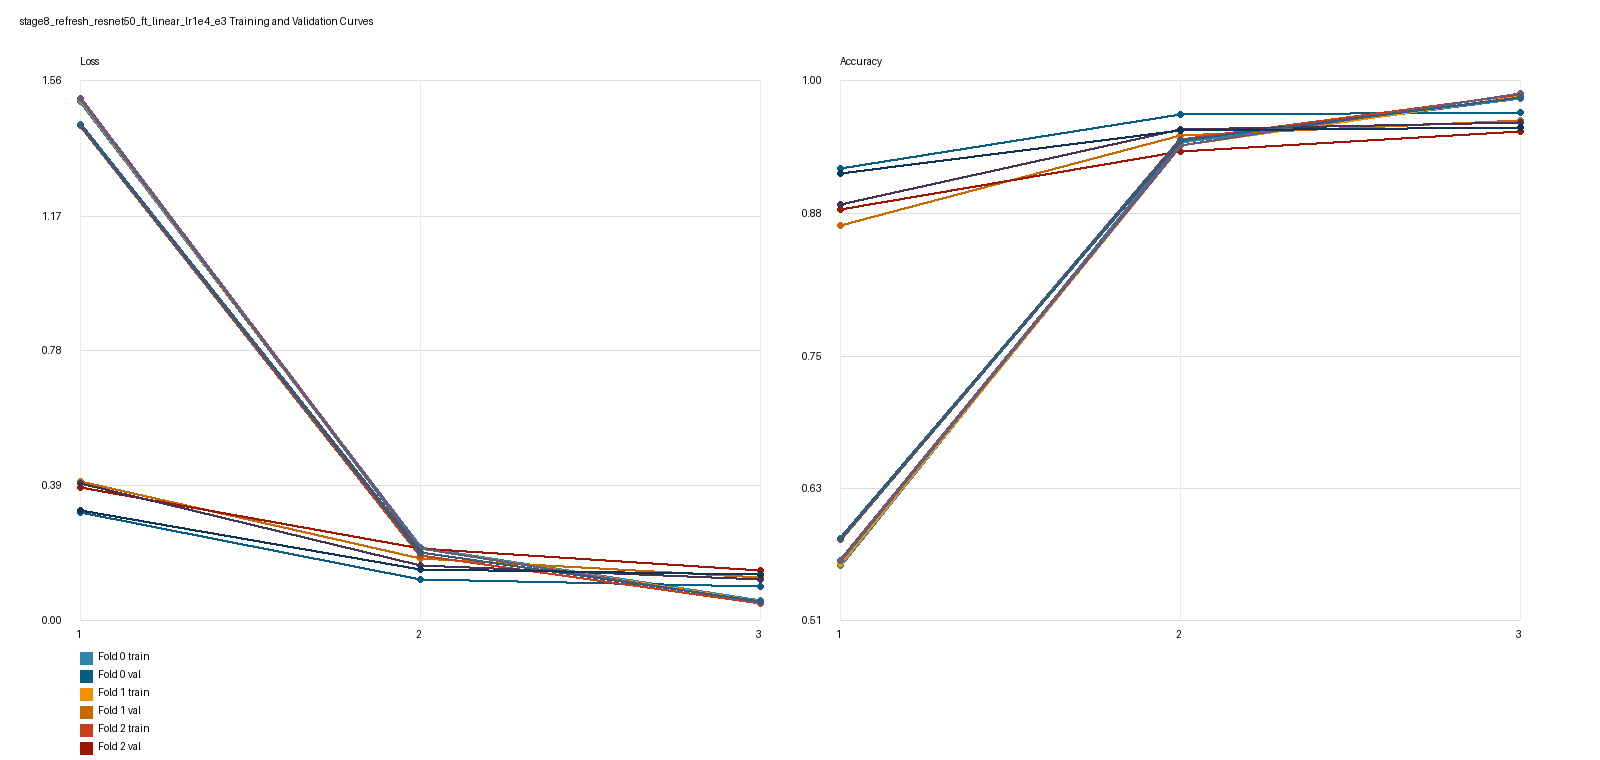

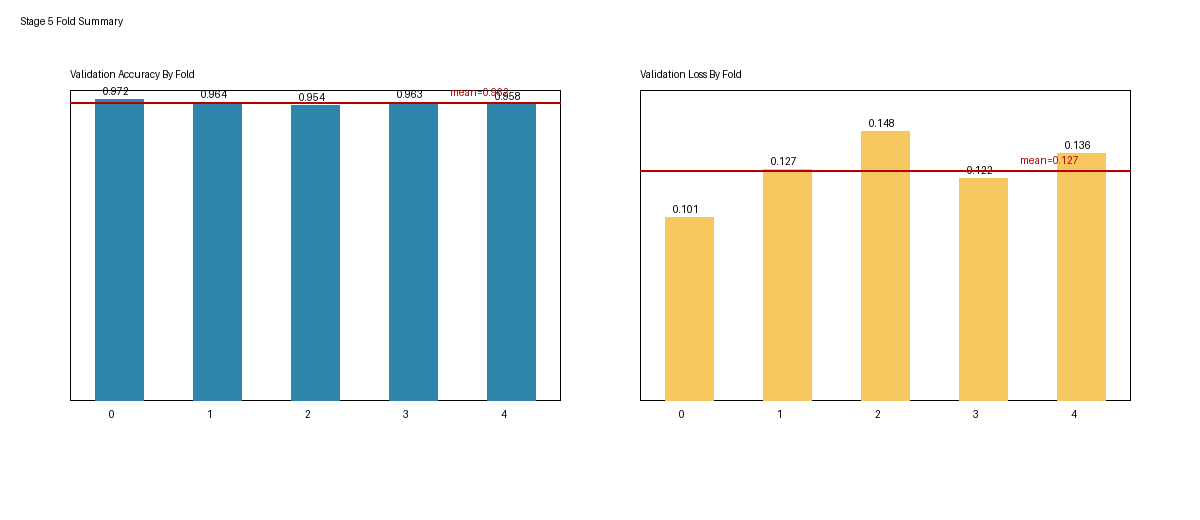

In [5]:
stage6_overview = pd.DataFrame(
    [
        {"field": "Validation predictions aggregated", "value": stage6_summary["num_validation_predictions"]},
        {"field": "Aggregated validation accuracy", "value": round(stage6_summary["overall_validation_accuracy"], 6)},
        {
            "field": "Stage 5 mean validation accuracy",
            "value": round(stage6_summary["aggregate_metrics_from_stage5"]["val_accuracy_at_best_epoch"]["mean"], 6),
        },
    ]
)
fold_summary_table = pd.read_csv(PATHS["stage6_fold_table"])

display(stage6_overview)
display(fold_summary_table)
show_image(PATHS["stage6_curves_png"], width=1000)
show_image(PATHS["stage6_fold_chart_png"], width=900)

### Aggregate confusion matrices

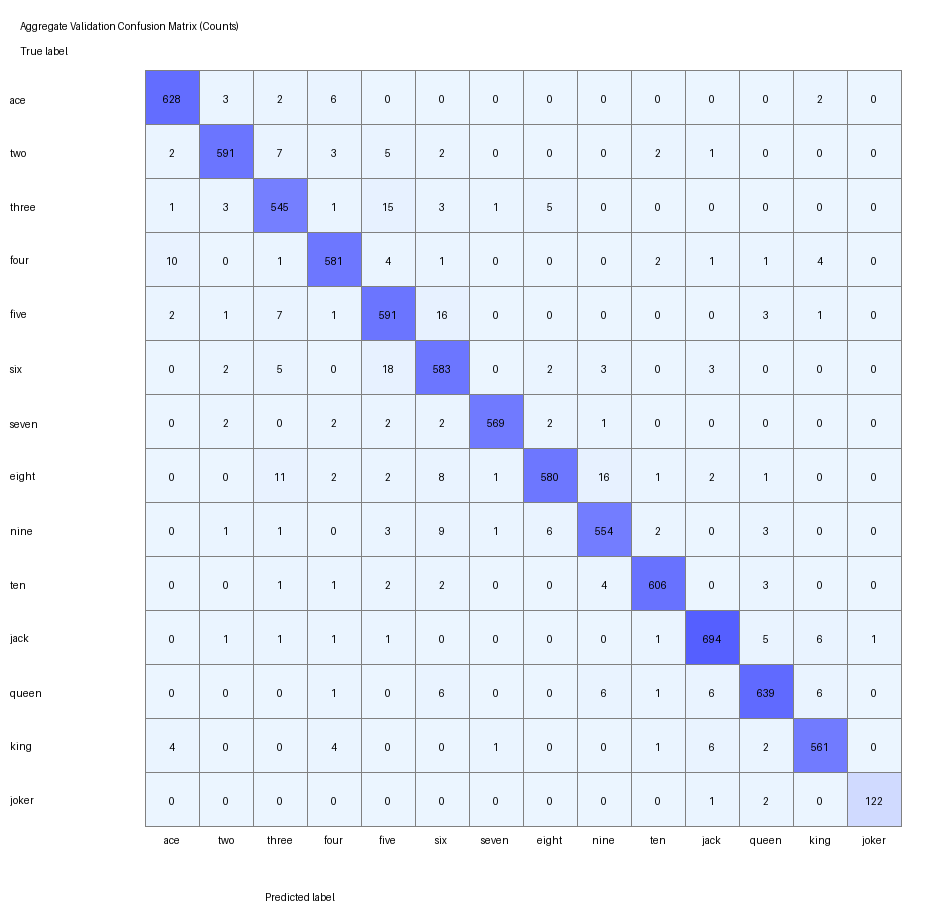

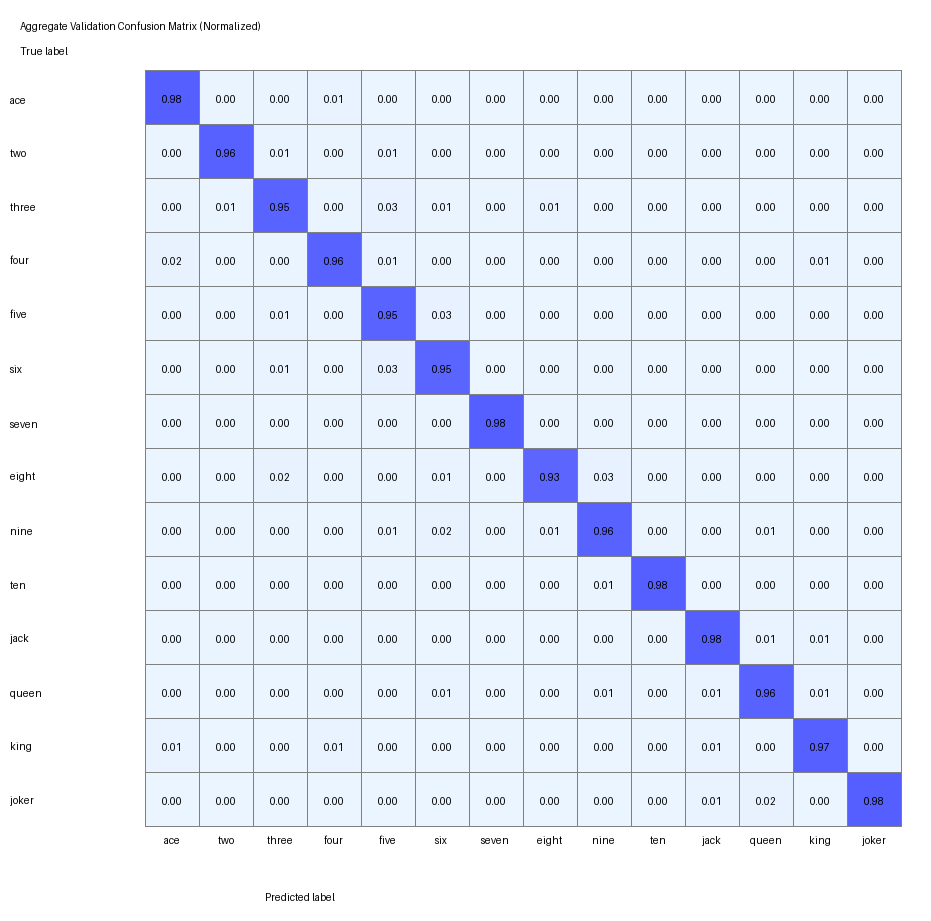

In [6]:
display(Markdown("### Aggregate confusion matrices"))
show_image(PATHS["stage6_confusion_counts_png"], width=950)
show_image(PATHS["stage6_confusion_normalized_png"], width=950)

### Sample predictions and misclassifications

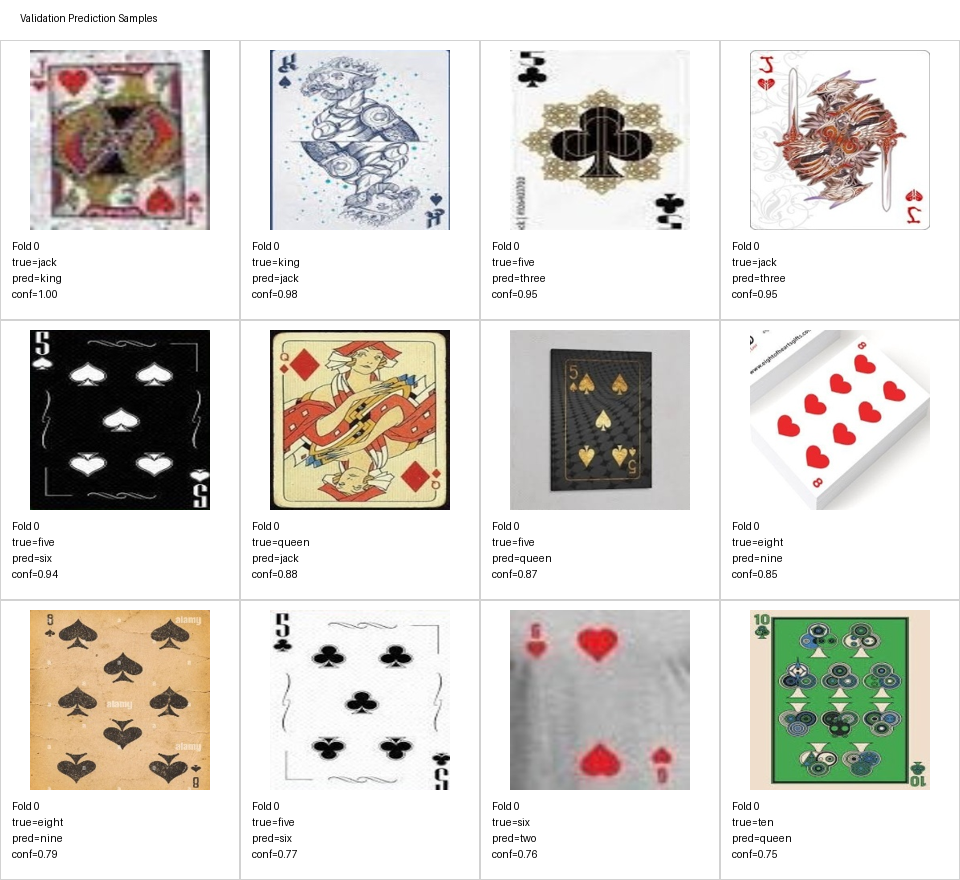

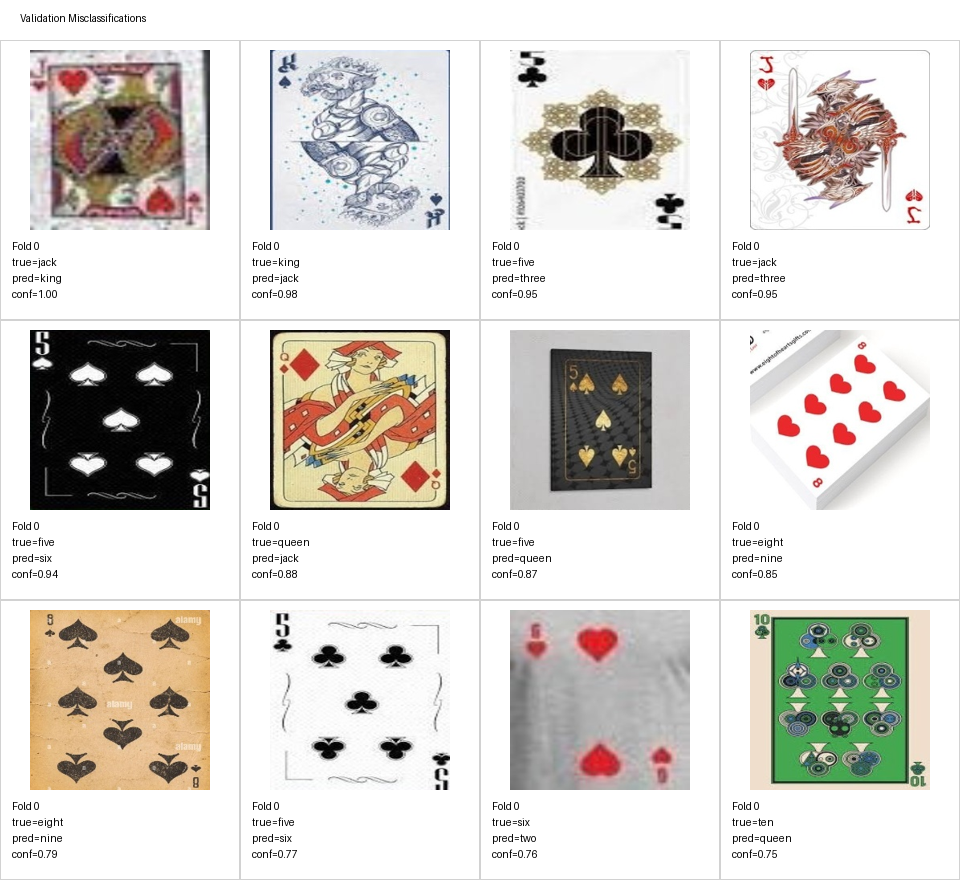

,fold,true_class_name,predicted_class_name,confidence,path
0,0,eight,nine,0.519406,C:\Users\golde\OneDrive - University of Virgin...
1,0,eight,nine,0.744692,C:\Users\golde\OneDrive - University of Virgin...
2,0,eight,queen,0.518167,C:\Users\golde\OneDrive - University of Virgin...
3,0,eight,nine,0.847494,C:\Users\golde\OneDrive - University of Virgin...
4,0,eight,six,0.475930,C:\Users\golde\OneDrive - University of Virgin...
5,0,eight,nine,0.792947,C:\Users\golde\OneDrive - University of Virgin...
6,0,eight,nine,0.562574,C:\Users\golde\OneDrive - University of Virgin...
7,0,eight,nine,0.669246,C:\Users\golde\OneDrive - University of Virgin...
8,0,eight,nine,0.725264,C:\Users\golde\OneDrive - University of Virgin...
9,0,eight,six,0.668584,C:\Users\golde\OneDrive - University of Virgin...


The Stage 6 aggregation produced 8154 validation predictions and 310 misclassifications.

In [7]:
validation_predictions = pd.read_csv(PATHS["stage6_predictions"])
misclassifications = pd.read_csv(PATHS["stage6_misclassifications"])

display(Markdown("### Sample predictions and misclassifications"))
show_image(PATHS["stage6_prediction_gallery_png"], width=1000)
show_image(PATHS["stage6_misclassification_gallery_png"], width=1000)

display(
    misclassifications[
        [
            "fold",
            "true_class_name",
            "predicted_class_name",
            "confidence",
            "path",
        ]
    ].head(12)
)

display(
    Markdown(
        f"The Stage 6 aggregation produced {len(validation_predictions)} validation predictions and "
        f"{len(misclassifications)} misclassifications."
    )
)

## Stage 7 Feature Maps

Stage 7 uses the best saved checkpoint from the refreshed Stage 5 run rather than retraining. The selection includes at least 2 face-card classes and 2 number-card classes drawn from correct validation predictions in the chosen fold.

,field,value
0,Checkpoint fold,0
1,Checkpoint val accuracy,0.971796
2,Layers,"backbone.layer3, backbone.layer4"
3,Device,cpu
4,Matplotlib version,3.10.8


,group_name,class_name,path,fold,confidence,predicted_class_name
0,face_cards,jack,C:\Users\golde\OneDrive - University of Virgin...,0,0.999994,jack
1,face_cards,queen,C:\Users\golde\OneDrive - University of Virgin...,0,0.999985,queen
2,number_cards,seven,C:\Users\golde\OneDrive - University of Virgin...,0,0.999999,seven
3,number_cards,five,C:\Users\golde\OneDrive - University of Virgin...,0,0.999997,five


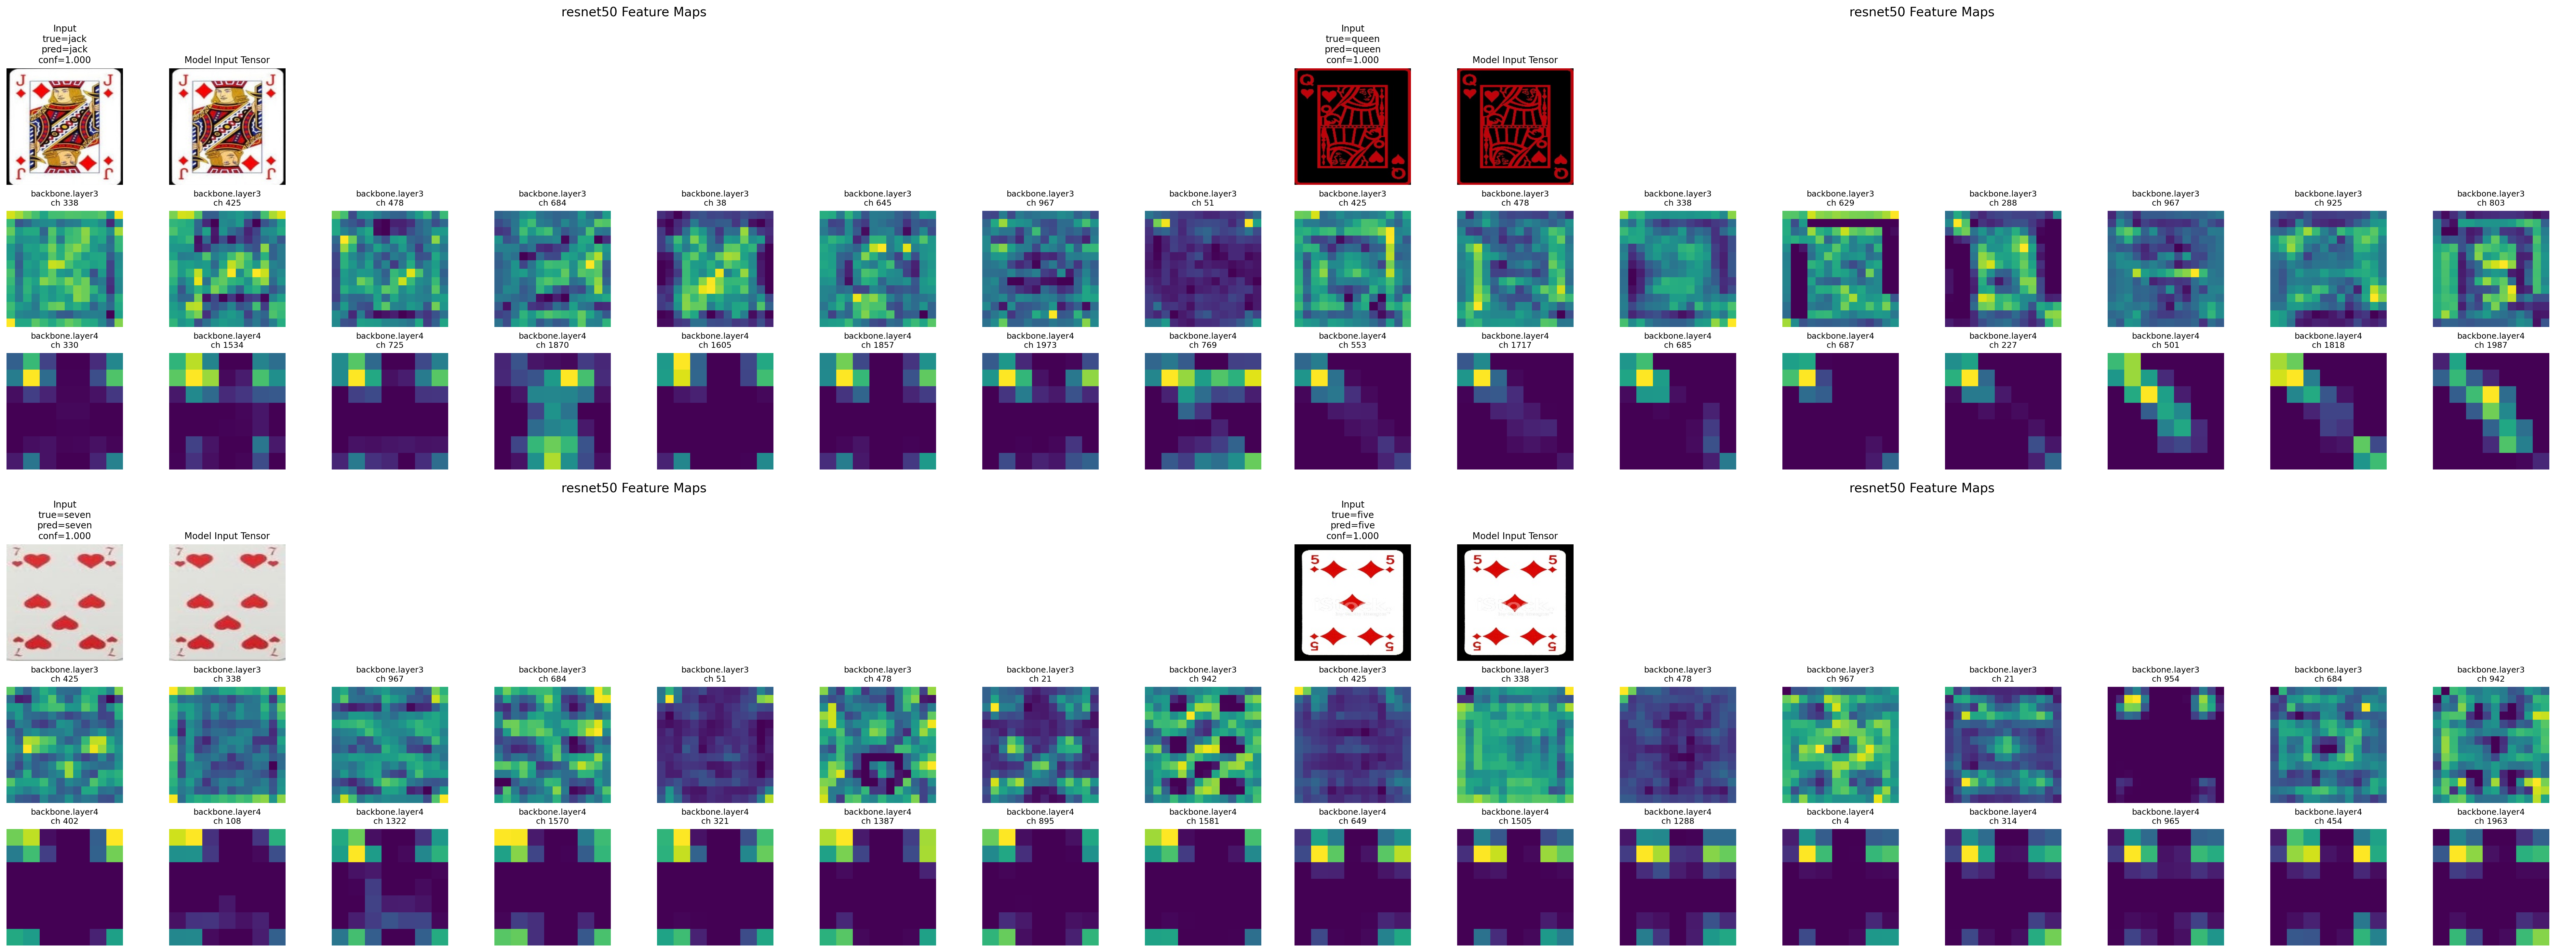

In [8]:
selected_examples = pd.read_csv(PATHS["stage7_examples_csv"])

stage7_overview = pd.DataFrame(
    [
        {"field": "Checkpoint fold", "value": stage7_summary["selected_checkpoint"]["fold"]},
        {"field": "Checkpoint val accuracy", "value": stage7_summary["selected_checkpoint"]["val_accuracy_at_best_epoch"]},
        {"field": "Layers", "value": ", ".join(stage7_summary["layer_names"])},
        {"field": "Device", "value": stage7_summary["device"]},
        {"field": "Matplotlib version", "value": stage7_summary["matplotlib_version"]},
    ]
)

display(stage7_overview)
display(selected_examples)
show_image(PATHS["stage7_overview_png"], width=1100)

### Individual feature-map renders

**face_cards__jack__train__jack_of_diamonds__155**

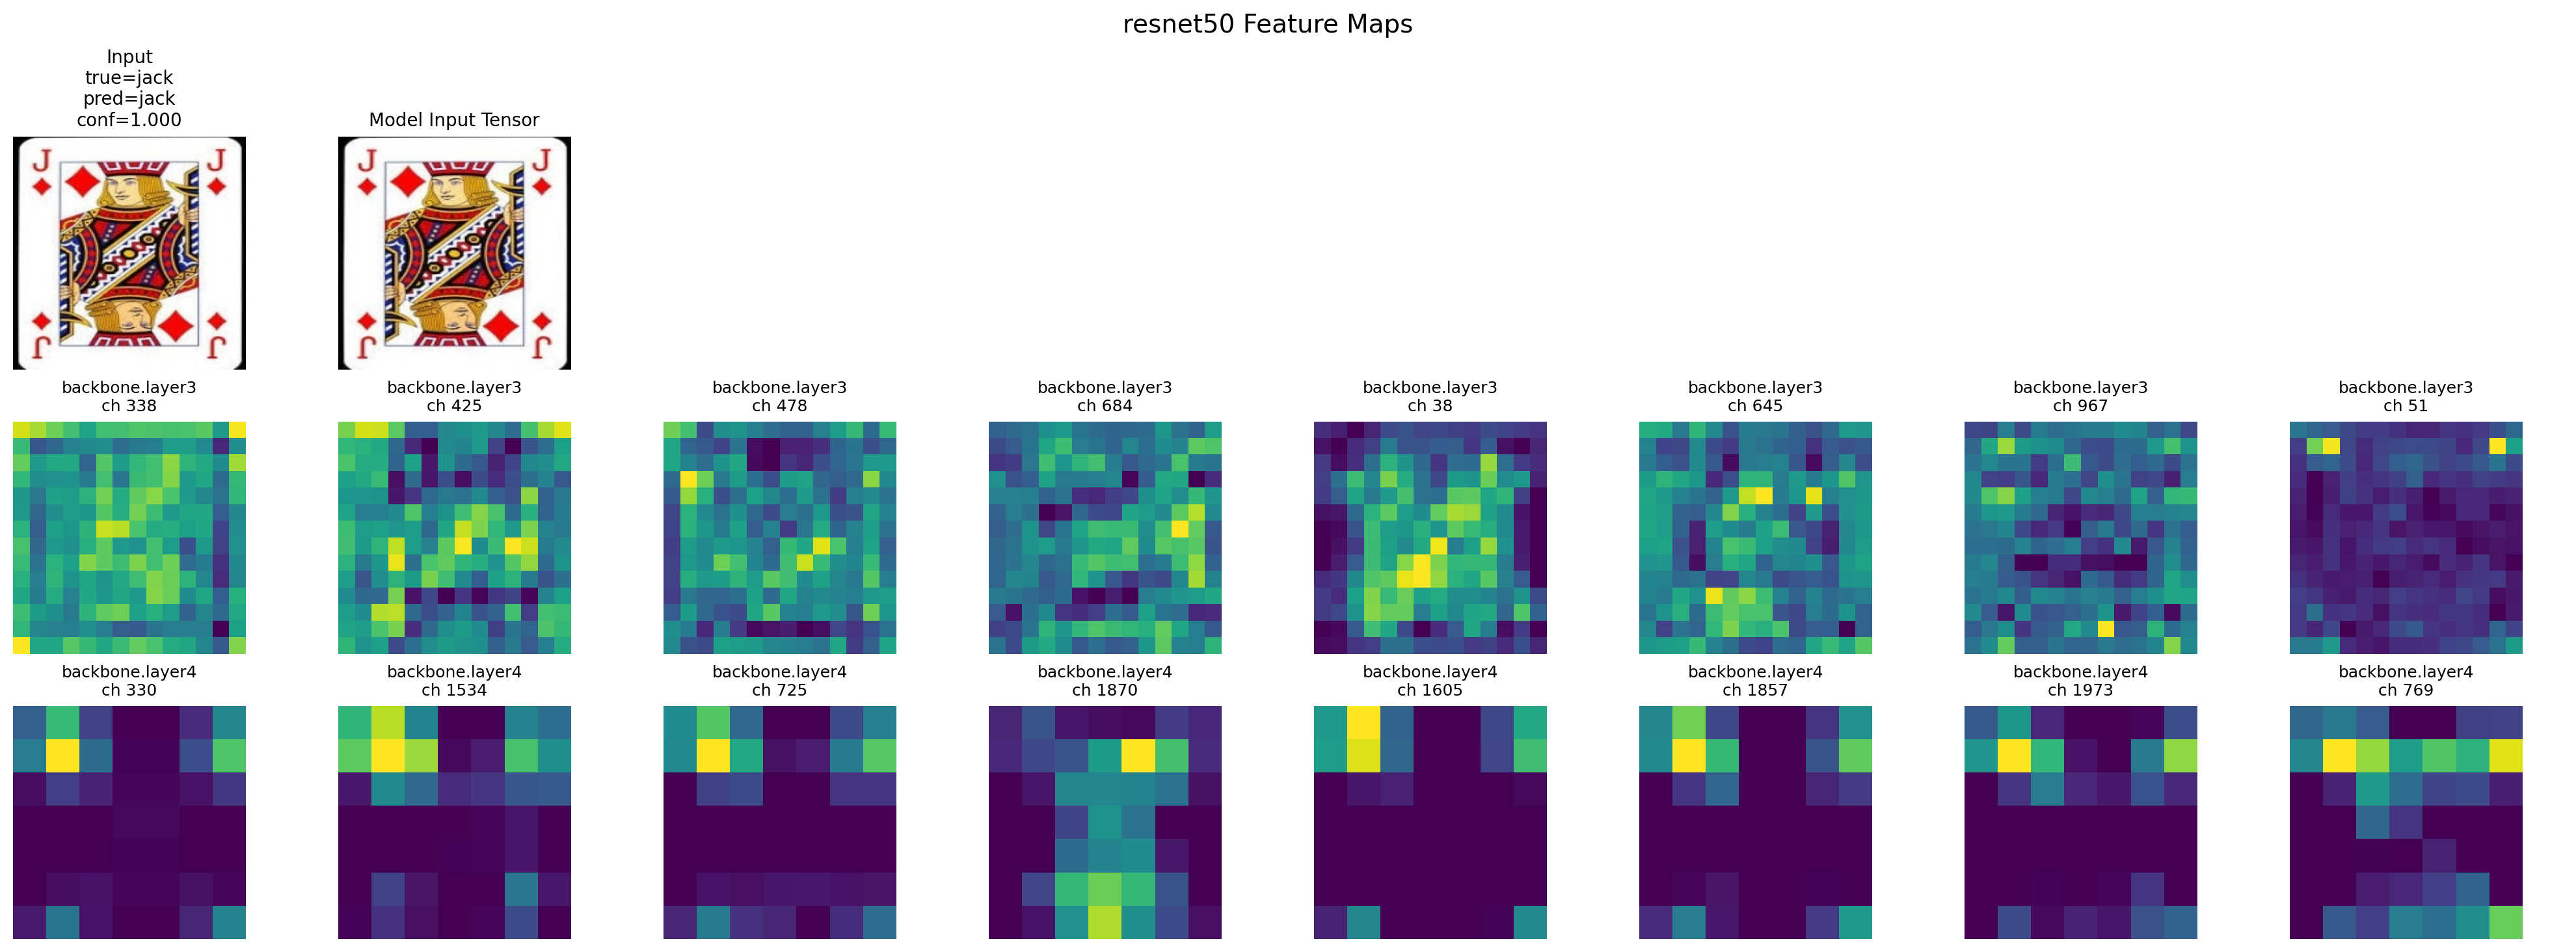

**face_cards__queen__train__queen_of_hearts__003**

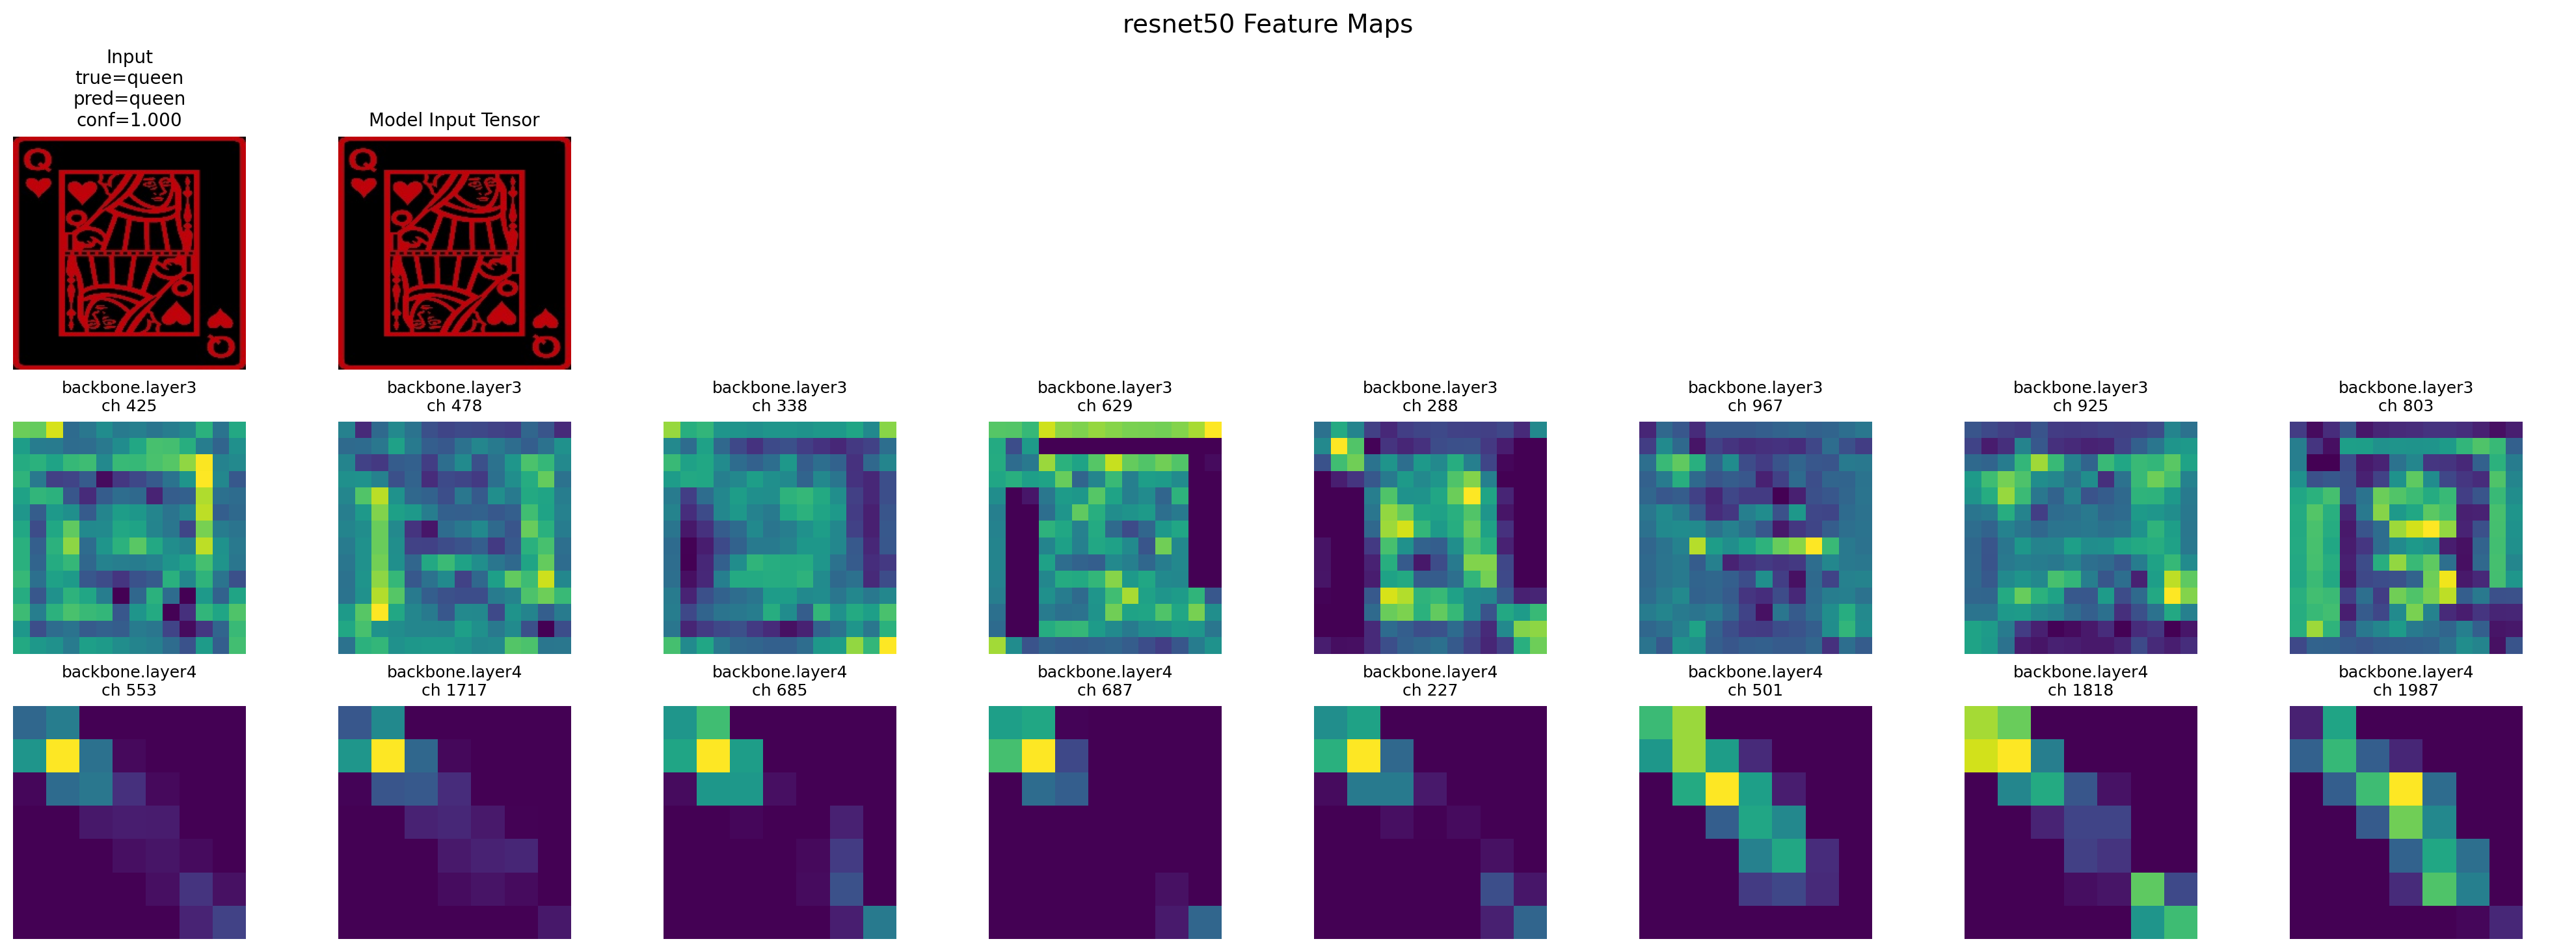

**number_cards__five__train__five_of_diamonds__036**

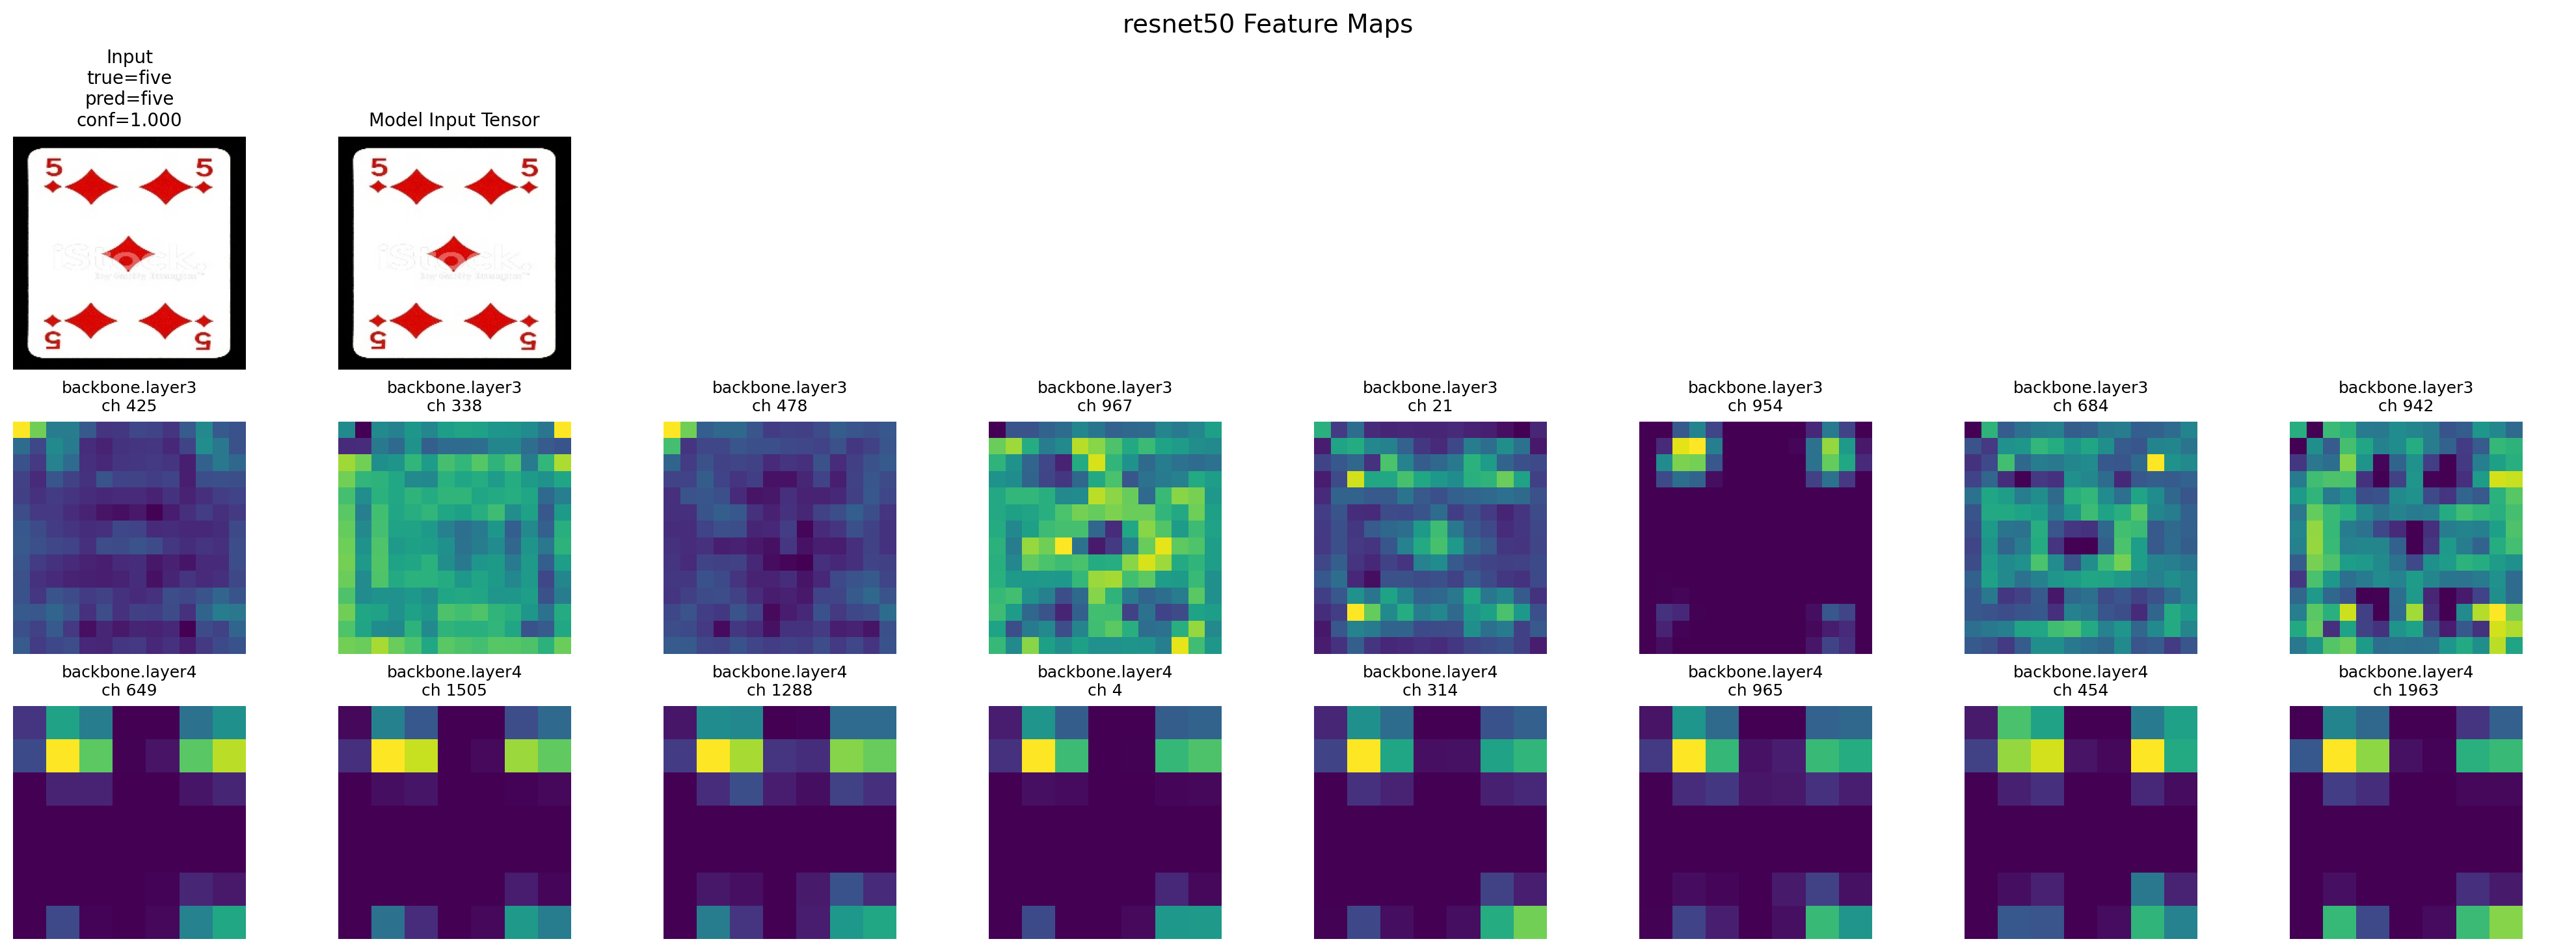

**number_cards__seven__train__seven_of_hearts__107**

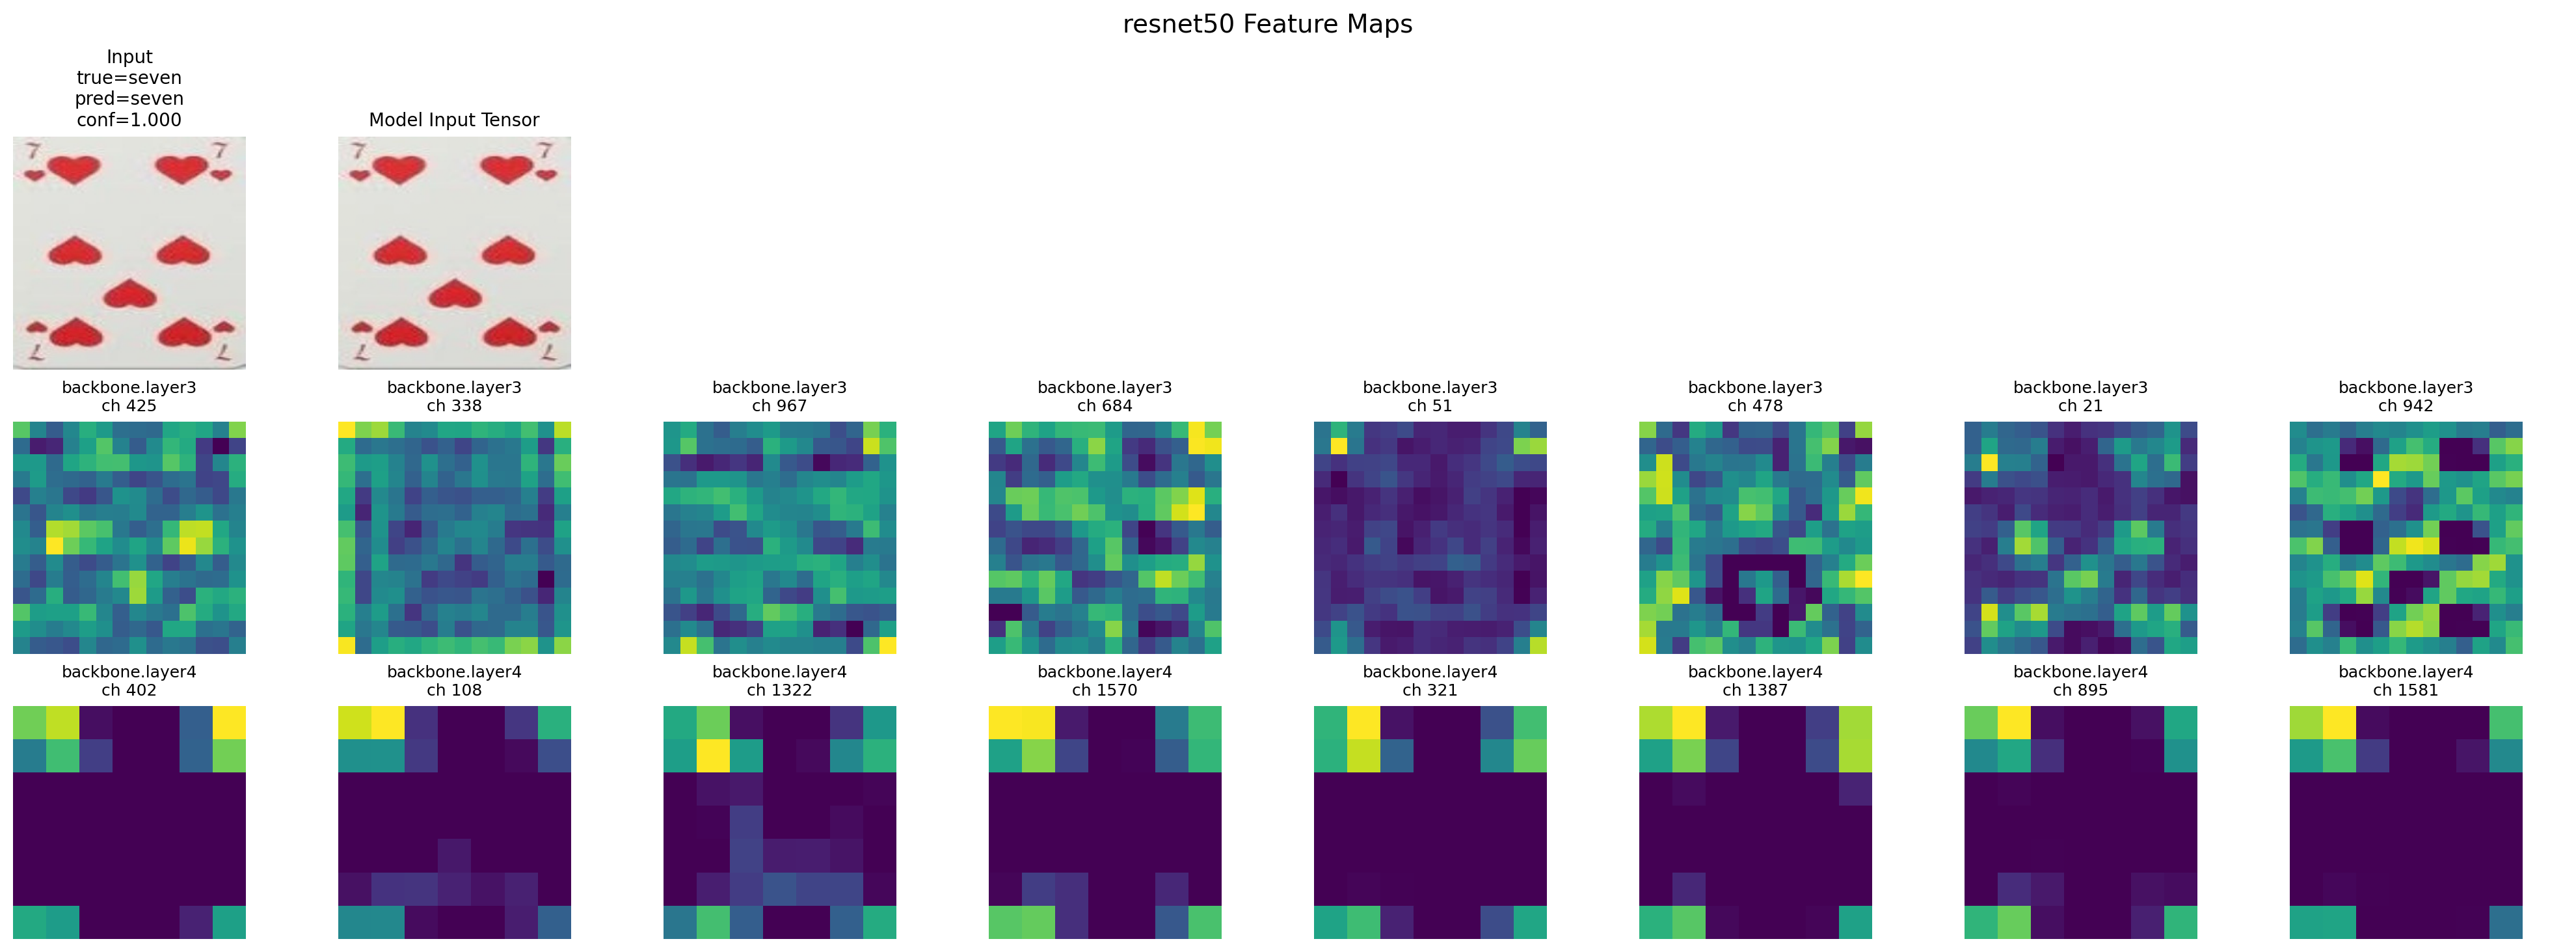

In [9]:
feature_map_paths = sorted(
    path
    for path in PATHS["stage7_dir"].glob("*.png")
    if path.name != "feature_map_overview.png"
)

display(Markdown("### Individual feature-map renders"))
for path in feature_map_paths:
    display(Markdown(f"**{path.stem}**"))
    show_image(path, width=900)

## Accuracy Improvement Status

The refreshed full-dataset baseline already exceeds 90% mean validation accuracy, so augmentation is no longer required for rubric compliance on the current dataset of record. Any additional improvement experiment shown below is therefore optional and should be interpreted as a bounded attempt to push performance higher without broad architecture search.

In [10]:
if stage8_comparison is None:
    display(
        Markdown(
            "No refreshed post-baseline comparison artifact was available when this notebook was built. "
            "The refreshed Stage 5 baseline therefore remains the current result of record in this notebook."
        )
    )
else:
    improvement_overview = pd.DataFrame(
        [
            {"field": "Baseline run name", "value": stage8_comparison["baseline_run_name"]},
            {"field": "Improved run name", "value": stage8_comparison["improved_run_name"]},
            {
                "field": "Baseline mean val accuracy",
                "value": round(stage8_comparison["baseline_metrics"]["val_accuracy_at_best_epoch"]["mean"], 6),
            },
            {
                "field": "Improved mean val accuracy",
                "value": round(stage8_comparison["improved_metrics"]["val_accuracy_at_best_epoch"]["mean"], 6),
            },
            {
                "field": "Validation accuracy delta",
                "value": round(stage8_comparison["metric_deltas"]["val_accuracy_at_best_epoch_mean_delta"], 6),
            },
            {
                "field": "Validation loss delta",
                "value": round(stage8_comparison["metric_deltas"]["val_loss_at_best_epoch_mean_delta"], 6),
            },
        ]
    )

    stage8_per_fold = pd.read_csv(stage8_comparison_csv_path)

    display(improvement_overview)
    display(stage8_per_fold)

,field,value
0,Baseline run name,stage5_refresh_resnet18_ft_linear_lr2e4
1,Improved run name,stage8_refresh_resnet50_ft_linear_lr1e4_e3
2,Baseline mean val accuracy,0.921756
3,Improved mean val accuracy,0.961981
4,Validation accuracy delta,0.040225
5,Validation loss delta,-0.149199


,fold,val_accuracy_at_best_epoch_baseline,val_accuracy_at_best_epoch_improved,delta_val_accuracy,val_loss_at_best_epoch_baseline,val_loss_at_best_epoch_improved,delta_val_loss
0,0,0.941754,0.971796,0.030043,0.216283,0.100823,-0.115460
1,1,0.928265,0.963826,0.035561,0.258367,0.127293,-0.131074
2,2,0.922134,0.954016,0.031882,0.273460,0.148314,-0.125146
3,3,0.896383,0.962600,0.066217,0.349801,0.122221,-0.227580
4,4,0.920245,0.957669,0.037423,0.282952,0.136217,-0.146735


## Conclusion

This notebook demonstrates a pretrained CNN workflow, real 5-fold cross-validation, saved result visualizations, and feature-map analysis for the full 14-class dataset. The main narrative is built around the refreshed full-dataset baseline and its downstream artifacts.

In [11]:
baseline_acc = stage5_summary["aggregate_metrics"]["val_accuracy_at_best_epoch"]["mean"]
baseline_std = stage5_summary["aggregate_metrics"]["val_accuracy_at_best_epoch"]["std"]

if stage8_comparison is None:
    conclusion = (
        f"The current result of record is `{stage5_summary['run_name']}` with mean 5-fold validation "
        f"accuracy **{baseline_acc:.4f} +/- {baseline_std:.4f}**."
    )
else:
    improved_run_name = stage8_comparison["improved_run_name"]
    improved_acc = stage8_comparison["improved_metrics"]["val_accuracy_at_best_epoch"]["mean"]
    prior_acc = stage8_comparison["baseline_metrics"]["val_accuracy_at_best_epoch"]["mean"]
    if improved_run_name == stage5_summary["run_name"]:
        conclusion = (
            f"The current result of record is `{stage5_summary['run_name']}`, which improved on the prior "
            f"canonical full-dataset run from **{prior_acc:.4f}** to **{improved_acc:.4f}** mean validation accuracy."
        )
    else:
        conclusion = (
            f"The refreshed Stage 5 baseline remains the strongest result of record at "
            f"**{baseline_acc:.4f} +/- {baseline_std:.4f}** mean validation accuracy."
        )

display(Markdown(conclusion))

The current result of record is `stage8_refresh_resnet50_ft_linear_lr1e4_e3`, which improved on the prior canonical full-dataset run from **0.9218** to **0.9620** mean validation accuracy.